# Solving differential equations


## 1. Euler method

I will  try to solve the following type of differential equation

$$
 \frac{\mathrm{d}y}{\mathrm{d}t} = f(t,y)
$$ 

We know that  
$$
\frac{\mathrm{d}y}{\mathrm{d}t} = \frac{y(t+h)-y(t)}{h},
$$

then 

$$
( y(t+h) = \frac{\mathrm{d}y}{\mathrm{d}t}h + y(t)
$$

Therefore, we can repetitively iterate this propagation: 

From the value y_n at step  n , corresponding to the time t , we can calculate the value ( y_{n+1}  at step  (n+1) , corresponding to the time  (t+h) :

$$
y_{n+1} = y_n + \frac{\mathrm{d}y}{\mathrm{d}t}h 
$$

which is

$$
y_{n+1} = y_n + f(t,y_n) h 
$$

### Example - Radioactive decay

$$ 
\dot{y} = -y
$$

or

$$
\frac{\mathrm{d}y}{\mathrm{d}t} = f(t,y) = -y
$$

Analytical solution: 
$$
y(t)=y_0 \exp(-t)
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y = 1 # Starting values

h = 0.1 # Step size

t_values = [0] # Collect data

y_values = [y] # Collect data

nmax = 200 #Number of iteratons

for i in range(1, nmax+1):
    f = - y #Function
    y = y + f * h 
    t_values.append(i*h)
    y_values.append(y)
  



Now we can compare the analytical value with the value we get from Euler method

In [ ]:
import numpy as np

t_final = nmax * h
exact = 1*np.exp(-t_final) 

print("Euler:", y_values[-1])
print("Exact:", exact)

Euler: 7.055079108655326e-10
Exact: 2.061153622438558e-09


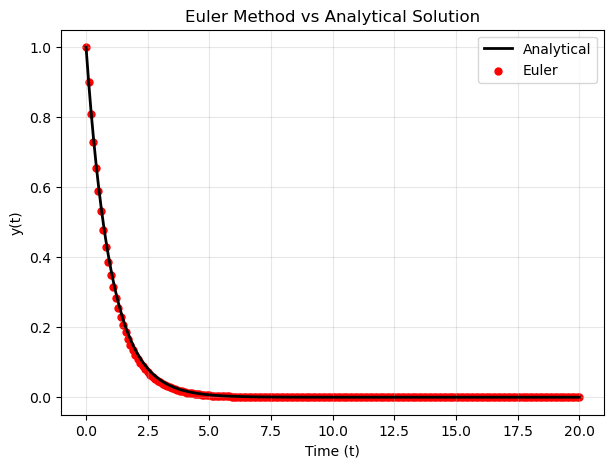

In [ ]:
# Analytical solution
t_exact = np.linspace(0, nmax*h, nmax)
y_exact = np.exp(-t_exact)

# Plot numerical and analytical solutions
plt.figure(figsize=(7,5))

plt.plot(t_exact, y_exact,color='black',linewidth=2,label='Analytical')

plt.scatter(t_values, y_values,color='red',s=25,label='Euler')

plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.title("Euler Method vs Analytical Solution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The Euler value is smaller than exact.
So Euler decays faster than exact solution.
We can just find the difference to understand a bit more

In [ ]:
error = abs(y_values[-1] - np.exp(-nmax*h))
rel_error = error / np.exp(-nmax*h)

print("Absolute error:", error)
print("Relative error:", rel_error)


Absolute error: 1.3556457115730253e-09
Relative error: 0.657712116561771


This much error is expected in the Euler method. We can visulaise it for better understanding by a error vs time graph

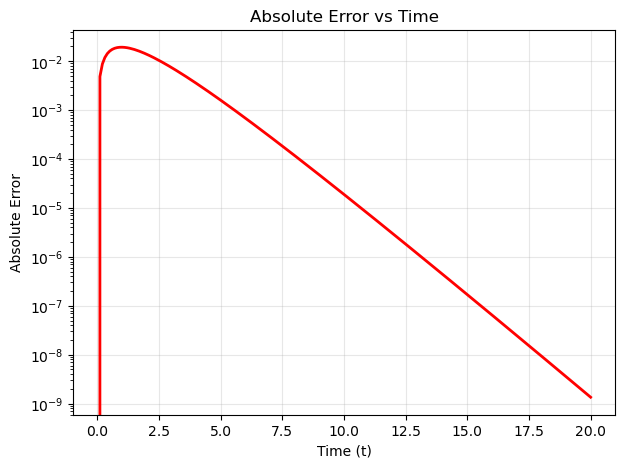

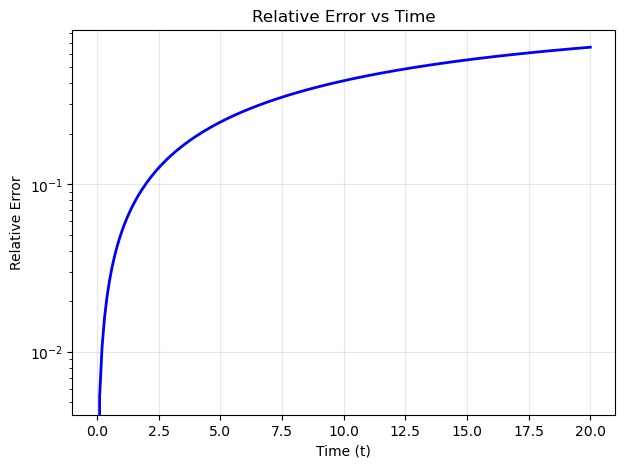

In [ ]:
# Computing absolute and relative error 
t_array = np.array(t_values)
y_array = np.array(y_values)

y_exact = np.exp(-t_array)

abs_error = np.abs(y_array - y_exact)
rel_error = abs_error / np.abs(y_exact)


# Absolute error
abs_error = np.abs(y_array - y_exact)

plt.figure(figsize=(7,5))

plt.plot(t_array, abs_error,color='red',linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Time")

plt.grid(alpha=0.3)
plt.yscale("log")
plt.show()

# Relative error

plt.figure(figsize=(7,5))

plt.plot(t_array, rel_error,color='blue',linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Relative Error")
plt.title("Relative Error vs Time")

plt.grid(alpha=0.3)
plt.yscale("log")
plt.show()



From the absolute error plot, it can be observed that the numerical error decreases gradually with time. The error reduces from approximately \(10^{-2}\) to \(10^{-9}\), indicating that the numerical solution approaches the analytical solution as time progresses.

From the error analysis, it can also be observed that:

- The absolute error decreases gradually with time
- The relative error becomes large at later times
- This occurs because the analytical solution approaches zero
- Therefore, relative error becomes less

We  can try to reduce error by redusing the step size . I think its better to try this and find out. Its better to find the error vs time for different step size together for better understanding.

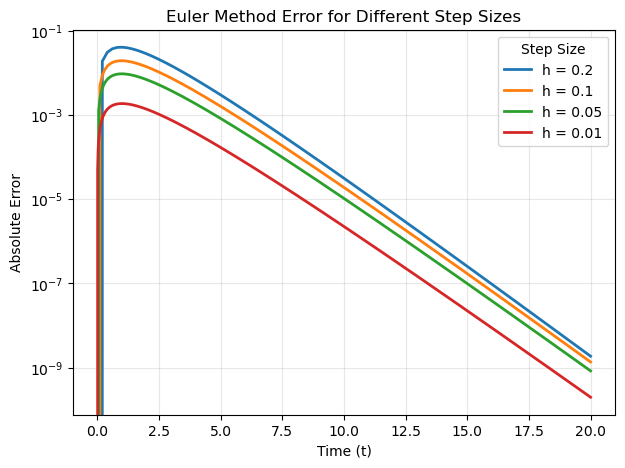

In [ ]:
# Error comparison for different step sizes

hs = [0.2, 0.1, 0.05, 0.01]

plt.figure(figsize=(7,5))

for h in hs:

    # Initial conditions
    y = 1
    t = 0

    # Store solution
    t_values = [t]
    y_values = [y]

    # Final simulation time
    t_final = 20
    nmax = int(t_final / h)

    # Euler method
    for i in range(1, nmax + 1):

        f = -y
        y = y + f*h

        t_values.append(i*h)
        y_values.append(y)

    # Convert to arrays
    t_array = np.array(t_values)
    y_array = np.array(y_values)

    # Exact solution
    y_exact = np.exp(-t_array)

    # Absolute error
    error = np.abs(y_array - y_exact)

    # Plot error
    plt.plot(t_array, error,linewidth=2,label=f"h = {h}")

plt.xlabel("Time (t)")
plt.ylabel("Absolute Error")
plt.title("Euler Method Error for Different Step Sizes")

plt.yscale("log")

plt.legend(title="Step Size")
plt.grid(alpha=0.3)

plt.show()



This clearly shows what we needed. The lower value of step size really reduces the error . Now to really understnd the acuuracy of this numerical method we can find the error vs step size plot. 

## Purpose of Error vs Step Size Plot

To evaluate the accuracy of the Euler method, we study how the numerical error depends on the step size (h).

By reducing h and measuring the corresponding error, we can observe the convergence behavior of the method.

A log-log plot of error vs step size reveals a power-law relationship of the form:
    Error ∝ h^p

The slope of this plot gives the order of accuracy (p).

For the Euler method, the slope is approximately 1, confirming that it is a first-order numerical method.

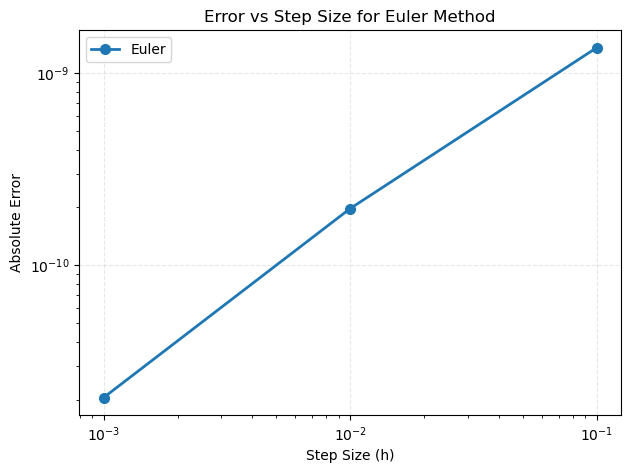

Estimated order of accuracy: 0.91
h = 0.1      error = 1.355646e-09
h = 0.01     error = 1.973970e-10
h = 0.001    error = 2.052244e-11


In [ ]:

# Final simulation time
t_final = 20

# Step sizes
hs = [0.1, 0.01, 0.001]

errors = []

# Compute error for each step size
for h in hs:

    y = 1
    nmax = int(t_final / h)

    # Euler method
    for _ in range(nmax):

        y = y - y*h

    # Exact solution at final time
    exact = np.exp(-t_final)

    # Absolute error
    error = np.abs(y - exact)

    errors.append(error)

# Convert to arrays
hs_array = np.array(hs)
errors_array = np.array(errors)

# Log-log error plot
plt.figure(figsize=(7,5))

plt.loglog(hs_array, errors_array,'o-',linewidth=2,markersize=7,label='Euler')

plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error")
plt.title("Error vs Step Size for Euler Method")

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

# Estimate order of accuracy
log_h = np.log(hs_array)
log_err = np.log(errors_array)

slope = np.polyfit(log_h, log_err, 1)[0]

print(f"Estimated order of accuracy: {slope:.2f}")

# Print errors
for h, err in zip(hs, errors):

    print(f"h = {h:<7}  error = {err:.6e}")


We can see
- Error decreases as h decreases
- The log-log plot is approximately linear
- The slope is close to 1, confirming first-order accuracy

### Define a function "EulerODE"

I  made a function for this Euler method as we now know this method is good for calculations with first order accuracy. Lets check if it works.

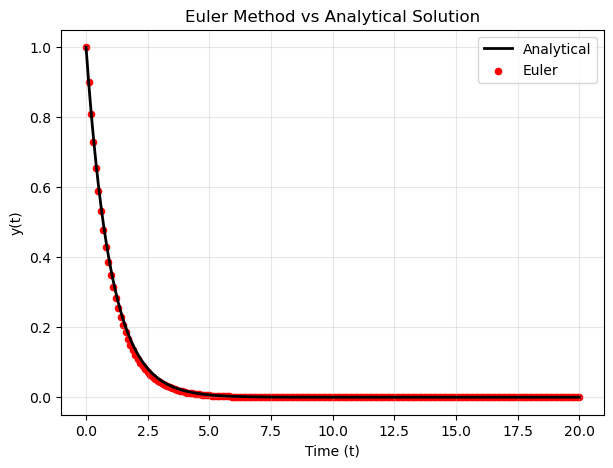

In [ ]:
import sys
sys.path.append("../src")
from euler import EulerODE
import numpy as np
import matplotlib.pyplot as plt
def f(t, y):
    return -y
t, y = EulerODE(f, 0, 1, 200, 0.1)
y_exact = np.exp(-t)

plt.figure(figsize=(7,5))

# Exact analytical solution
plt.plot(t, y_exact,color='black',linewidth=2,label='Analytical')

# Euler numerical solution
plt.scatter(t, y,color='red',s=20,label='Euler')

plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.title("Euler Method vs Analytical Solution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

The numerical solution closely follows the analytic solution which shows that the implementation is correct. We can also do  convergence test and error analysis.

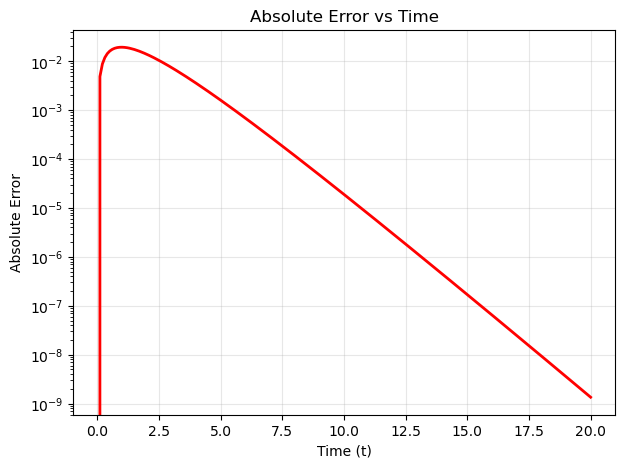

In [ ]:
# Absolute error analysis
abs_error = np.abs(y - y_exact)

plt.figure(figsize=(7,5))

plt.plot(t, abs_error,color='red',linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Time")

plt.grid(alpha=0.3)
plt.yscale("log")
plt.show()

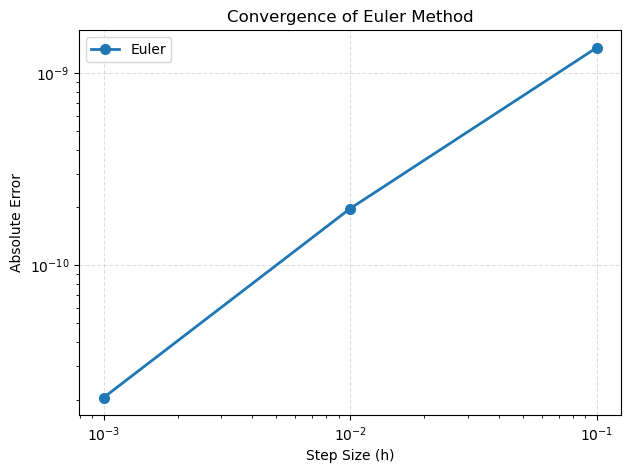

Estimated order of accuracy: 0.91


In [ ]:
# Convergence / accuracy test

hs = [0.1, 0.01, 0.001]
errors = []

# Compute error for different step sizes
for h in hs:

    t, y = EulerODE(f, 0, 1, int(20/h), h)

    # Exact solution at final time
    exact = np.exp(-20)

    # Absolute error
    error = np.abs(y[-1] - exact)

    errors.append(error)

# Log-log convergence plot
plt.figure(figsize=(7,5))

plt.loglog(hs, errors,'o-',linewidth=2,markersize=7,label='Euler')

plt.xlabel("Step Size (h)")
plt.ylabel("Absolute Error")
plt.title("Convergence of Euler Method")

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.show()

# Estimate order of accuracy
slope = np.polyfit(np.log(hs), np.log(errors), 1)[0]

print(f"Estimated order of accuracy: {slope:.2f}")

The log-log convergence plot shows that the numerical error decreases as the step size becomes smaller. The slope of the fitted line approximates the order of accuracy of the Euler method and is found to be close to 1, confirming that Euler is a first-order numerical method.

## Conclusion

The function implemented for Euler function is validated against an analytical solution and shown to produce accurate results for small step sizes.
I was able to understand about the errors of Euler method. All the observations confirms that the implementation is mathematically  consistant and correct.
At the same time, the results highlight the limitations of the method, particularly its relatively low accuracy and sensitivity to step size.
